In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from matplotlib.lines import Line2D
from scipy.stats import chi2_contingency

## Build a general graph with the resulting relationships

In [2]:
all_nmd_escape_final = pd.read_csv("data/all_nmd_escape_final_wo_in_clinvar.csv")
all_nmd_undergo_final = pd.read_csv("data/all_nmd_undergo_final_wo_in_clinvar.csv")

In [3]:
all_nmd_escape_final

,CHROM,POS,ID,REF,ALT,AC,Consequence,IMPACT,SYMBOL,Gene,...,LoF_flags,LoF_info,LOEUF,pext,NMD_escape,Context,Codon_position,Initial_Codon,Stop_Codon,Significance
0,chr5,112839436,rs1765536013,C,A,1.0,stop_gained,HIGH,APC,ENSG00000134982,...,NaN,PERCENTILE:0.450304735114862,0.161,0.904855,YES,TATCATCTTTGTCATCAGCTGAAGA,2,TCA,TAA,pathogenic
1,chr9,5922160,NaN,G,T,1.0,stop_gained,HIGH,KIAA2026,ENSG00000183354,...,NaN,PERCENTILE:0.607731305449937,0.336,0.732065,YES,GAGATTCACAGTCAATTCTTGTTAG,2,TCA,TAA,pathogenic
2,chr9,5921681,NaN,G,A,1.0,stop_gained,HIGH,KIAA2026,ENSG00000183354,...,NaN,PERCENTILE:0.683618504435995,0.336,0.732065,YES,ACTCCAACTAAACAGCAACAAGTAG,1,CAG,TAG,pathogenic
3,chr9,5919982,NaN,G,C,1.0,stop_gained,HIGH,KIAA2026,ENSG00000183354,...,NaN,PERCENTILE:0.952788339670469,0.336,0.732065,YES,TATCACTGACTTCAGTAATTAAGTC,2,TCA,TGA,pathogenic
4,chr9,5921675,NaN,G,A,1.0,stop_gained,HIGH,KIAA2026,ENSG00000183354,...,NaN,PERCENTILE:0.6845690747782,0.336,0.732065,YES,ACTAAACAGCAACAAGTAGATTATA,1,CAA,TAA,pathogenic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1847,chr1,24350118,rs1390189012,C,T,4.0,stop_gained,HIGH,GRHL3,ENSG00000158055,...,NaN,PERCENTILE:0.934217799889442,0.158,0.983307,YES,AAGAAATGCAAGCGAGGAATCTTAG,1,CGA,TGA,benign
1848,chr1,23083263,NaN,C,T,12.0,stop_gained,HIGH,KDM1A,ENSG00000004487,...,NaN,PERCENTILE:0.961611554541999,0.276,0.815216,YES,CTGAGTGGGCTGCGAGAAGCGGGAA,1,CGA,TGA,benign
1849,chr1,17409101,rs2075397397,G,A,2.0,stop_gained,HIGH,RCC2,ENSG00000179051,...,NaN,PERCENTILE:0.992989165073295,0.334,0.999379,YES,GAATACAACCCCCGAACCCTCTGAT,1,CGA,TGA,benign
1850,chr1,16251562,rs532744461,G,T,57.0,stop_gained,HIGH,FBXO42,ENSG00000037637,...,NaN,PERCENTILE:0.585886722376973,0.274,0.997337,YES,GGCAGACTCCTTCAGGTTCCCGGGA,2,TCA,TAA,benign


In [4]:
all_nmd_undergo_final

,CHROM,POS,ID,REF,ALT,AC,Consequence,IMPACT,SYMBOL,Gene,...,LoF_flags,LoF_info,LOEUF,pext,NMD_escape,Context,Codon_position,Initial_Codon,Stop_Codon,Significance
0,chr1,180090734,NaN,G,A,1.0,stop_gained,HIGH,CEP350,ENSG00000135837,...,NaN,PERCENTILE:0.689116955313235,0.184,0.637977,NO,CGGCAAAGAATTGGAAATCACTAAC,2,TGG,TAG,pathogenic
1,chr1,180093304,NaN,C,A,1.0,stop_gained,HIGH,CEP350,ENSG00000135837,...,NaN,PERCENTILE:0.769617276031644,0.184,0.637977,NO,ATTTTGAGGTGTCATCTTTGCTGTC,2,TCA,TAA,pathogenic
2,chr1,179990579,NaN,A,T,1.0,stop_gained,HIGH,CEP350,ENSG00000135837,...,NaN,PERCENTILE:0.0206328843275604,0.184,0.656119,NO,GTCATGGATACCAAGAAGTCTTCTA,1,AAG,TAG,pathogenic
3,chr1,180094072,NaN,C,G,1.0,stop_gained,HIGH,CEP350,ENSG00000135837,...,NaN,PERCENTILE:0.851721188796237,0.184,0.931839,NO,ACCAGCAGTCTTCAGTGGATTCACA,2,TCA,TGA,pathogenic
4,chr1,179996755,NaN,C,T,1.0,stop_gained,HIGH,CEP350,ENSG00000135837,...,NaN,PERCENTILE:0.0639298695745136,0.184,0.631281,NO,TTTTTAAATGATCGACCAGCAATTG,1,CGA,TGA,pathogenic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9517,chr11,61528140,rs368961138,G,A,5.0,stop_gained,HIGH,SYT7,ENSG00000011347,...,NaN,PERCENTILE:0.6045608927705,0.300,0.982997,NO,GAGGGTTGCAGCCGAGAGAACCTGG,1,CGA,TGA,benign
9518,chr11,64767020,NaN,G,A,5.0,stop_gained,HIGH,SF1,ENSG00000168066,...,NaN,PERCENTILE:0.761458333333333,0.177,0.512394,NO,CCTCCCAGTGGGCAGCCCCCACCCC,1,CAG,TAG,benign
9519,chr1,183261240,NaN,G,A,7.0,stop_gained,HIGH,NMNAT2,ENSG00000157064,...,NaN,PERCENTILE:0.773809523809524,0.265,0.955024,NO,GCCGACACAGACCGAATCATGAATC,1,CGA,TGA,benign
9520,chr20,10275537,NaN,C,T,3.0,stop_gained,HIGH,SNAP25,ENSG00000132639,...,NaN,PERCENTILE:0.0740740740740741,0.229,0.763338,NO,GAGGAGATGCAGCGAAGGGCTGACC,1,CGA,TGA,benign


In [5]:
all_nmd = pd.concat([all_nmd_escape_final, all_nmd_undergo_final], ignore_index=True)

In [6]:
all_nmd

,CHROM,POS,ID,REF,ALT,AC,Consequence,IMPACT,SYMBOL,Gene,...,LoF_flags,LoF_info,LOEUF,pext,NMD_escape,Context,Codon_position,Initial_Codon,Stop_Codon,Significance
0,chr5,112839436,rs1765536013,C,A,1.0,stop_gained,HIGH,APC,ENSG00000134982,...,NaN,PERCENTILE:0.450304735114862,0.161,0.904855,YES,TATCATCTTTGTCATCAGCTGAAGA,2,TCA,TAA,pathogenic
1,chr9,5922160,NaN,G,T,1.0,stop_gained,HIGH,KIAA2026,ENSG00000183354,...,NaN,PERCENTILE:0.607731305449937,0.336,0.732065,YES,GAGATTCACAGTCAATTCTTGTTAG,2,TCA,TAA,pathogenic
2,chr9,5921681,NaN,G,A,1.0,stop_gained,HIGH,KIAA2026,ENSG00000183354,...,NaN,PERCENTILE:0.683618504435995,0.336,0.732065,YES,ACTCCAACTAAACAGCAACAAGTAG,1,CAG,TAG,pathogenic
3,chr9,5919982,NaN,G,C,1.0,stop_gained,HIGH,KIAA2026,ENSG00000183354,...,NaN,PERCENTILE:0.952788339670469,0.336,0.732065,YES,TATCACTGACTTCAGTAATTAAGTC,2,TCA,TGA,pathogenic
4,chr9,5921675,NaN,G,A,1.0,stop_gained,HIGH,KIAA2026,ENSG00000183354,...,NaN,PERCENTILE:0.6845690747782,0.336,0.732065,YES,ACTAAACAGCAACAAGTAGATTATA,1,CAA,TAA,pathogenic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11369,chr11,61528140,rs368961138,G,A,5.0,stop_gained,HIGH,SYT7,ENSG00000011347,...,NaN,PERCENTILE:0.6045608927705,0.300,0.982997,NO,GAGGGTTGCAGCCGAGAGAACCTGG,1,CGA,TGA,benign
11370,chr11,64767020,NaN,G,A,5.0,stop_gained,HIGH,SF1,ENSG00000168066,...,NaN,PERCENTILE:0.761458333333333,0.177,0.512394,NO,CCTCCCAGTGGGCAGCCCCCACCCC,1,CAG,TAG,benign
11371,chr1,183261240,NaN,G,A,7.0,stop_gained,HIGH,NMNAT2,ENSG00000157064,...,NaN,PERCENTILE:0.773809523809524,0.265,0.955024,NO,GCCGACACAGACCGAATCATGAATC,1,CGA,TGA,benign
11372,chr20,10275537,NaN,C,T,3.0,stop_gained,HIGH,SNAP25,ENSG00000132639,...,NaN,PERCENTILE:0.0740740740740741,0.229,0.763338,NO,GAGGAGATGCAGCGAAGGGCTGACC,1,CGA,TGA,benign


In [7]:
cross_tab_all = pd.crosstab([all_nmd['NMD_escape'], all_nmd['Significance']], all_nmd['Codon_position'])
print(cross_tab_all)

Codon_position              1    2    3
NMD_escape Significance                
NO         benign        3764  492  505
           pathogenic    2970  822  969
YES        benign         675  138  113
           pathogenic     591  177  158


In [8]:
chi2, p_value, _, _ = chi2_contingency(cross_tab_all)
print(f"Chi-squared value: {chi2}")
print(f"P-value: {p_value}")

Chi-squared value: 352.741225575466
P-value: 3.9807347306871246e-73


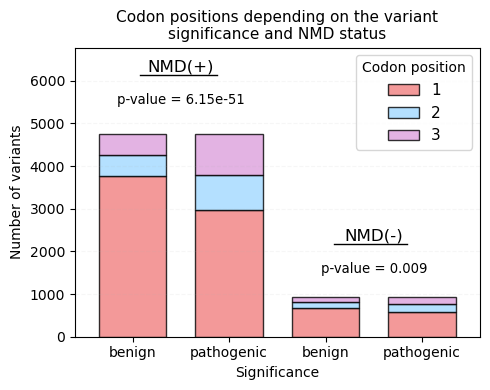

In [9]:
custom_colors = ['#f08080', '#a1d9ff', '#dda0dd']

fig, ax = plt.subplots(figsize=(5, 4))
cross_tab_all.plot(kind='bar', stacked=True, alpha=0.8, edgecolor='black', linewidth=1, width=0.7, color=custom_colors, ax=ax)

plt.title('Codon positions depending on the variant\nsignificance and NMD status', fontsize=11)
plt.xlabel('Significance', fontsize=10)
plt.ylabel('Number of variants', fontsize=10)

labels = cross_tab_all.index.get_level_values('Significance')
plt.xticks(ticks=range(len(labels)), labels=labels, rotation=0, fontsize=10)

plt.yticks(fontsize=10)
plt.legend(title='Codon position', fontsize=11, loc='upper right')
plt.grid(True, axis='y', linestyle='--', alpha=0.1)

plt.ylim(top=cross_tab_all.max().max() * 1.8)

max_value = cross_tab_all.max().max()
plt.text(0.5, max_value * 1.65, 'NMD(+)', fontsize=12, ha='center')
plt.text(0.5, max_value * 1.45, 'p-value = 6.15e-51', fontsize=9.5, ha='center')
plt.text(2.5, max_value * 0.6, 'NMD(-)', fontsize=12, ha='center')
plt.text(2.5, max_value * 0.4, 'p-value = 0.009', fontsize=9.5, ha='center')

plt.axhline(y=max_value * 1.63, xmin=0.35, xmax=0.16, color='black', linewidth=1)
plt.axhline(y=max_value * 0.58, xmin=0.64, xmax=0.82, color='black', linewidth=1)

plt.tight_layout()
plt.savefig('../images/final_plot_wo_clinvar.png', dpi=300)
plt.show()

### 2-A. Bar plot of proportions of stop codons and codon positions for all four variant groups (NMD+ ben/pat, NMD- ben/pat)

In [10]:
pat_escape_variants = all_nmd_escape_final.loc[all_nmd_escape_final['Significance'] == 'pathogenic']
ben_escape_variants = all_nmd_escape_final.loc[all_nmd_escape_final['Significance'] == 'benign']

pat_estop_codon_percent = pat_escape_variants['Stop_Codon'].value_counts(normalize=True) * 100
ben_estop_codon_percent = ben_escape_variants['Stop_Codon'].value_counts(normalize=True) * 100

stop_codon_df_escape = pd.DataFrame({
    'Singleton_Escape': pat_estop_codon_percent,
    'Benign_Escape': ben_estop_codon_percent
}).reset_index().rename(columns={'index': 'Stop_Codon'})

In [11]:
stop_codon_df_escape

,Stop_Codon,Singleton_Escape,Benign_Escape
0,TAA,27.105832,16.630670
1,TAG,49.136069,34.773218
2,TGA,23.758099,48.596112


In [12]:
pat_undergo_variants = all_nmd_undergo_final.loc[all_nmd_undergo_final['Significance'] == 'pathogenic']
ben_undergo_variants = all_nmd_undergo_final.loc[all_nmd_undergo_final['Significance'] == 'benign']

pat_ustop_codon_percent = pat_undergo_variants['Stop_Codon'].value_counts(normalize=True) * 100
ben_ustop_codon_percent = ben_undergo_variants['Stop_Codon'].value_counts(normalize=True) * 100

stop_codon_df_undergo = pd.DataFrame({
    'Singleton_Undergo': pat_ustop_codon_percent,
    'Benign_Undergo': ben_ustop_codon_percent
}).reset_index().rename(columns={'index': 'Stop_Codon'})

In [13]:
stop_codon_df_undergo

,Stop_Codon,Singleton_Undergo,Benign_Undergo
0,TAA,25.561857,14.114682
1,TAG,46.460828,26.906112
2,TGA,27.977316,58.979206


In [14]:
stop_codon_df = stop_codon_df_escape.merge(stop_codon_df_undergo, on="Stop_Codon").set_index("Stop_Codon")
stop_codon_df = stop_codon_df.sort_index()

stop_codon_df

,Singleton_Escape,Benign_Escape,Singleton_Undergo,Benign_Undergo
Stop_Codon,,,,
TAA,27.105832,16.630670,25.561857,14.114682
TAG,49.136069,34.773218,46.460828,26.906112
TGA,23.758099,48.596112,27.977316,58.979206


In [15]:
# colors = ['mediumpurple', 'slategrey']

# fig, ax = plt.subplots(figsize=(7, 4))

# stop_codon_df_escape.plot(kind='line', x='Stop_Codon', marker='o', linestyle='--', color=colors, ax=ax)
# stop_codon_df_undergo.plot(kind='line', x='Stop_Codon', marker='o', linestyle='-', color=colors, ax=ax)

# custom_lines = [Line2D([0], [0], color='mediumpurple', lw=2, linestyle='--'),
#                 Line2D([0], [0], color='slategrey', lw=2, linestyle='--'),
#                 Line2D([0], [0], color='mediumpurple', lw=2, linestyle='-'),
#                 Line2D([0], [0], color='slategrey', lw=2, linestyle='-')]

# ax.legend(custom_lines, ['Singleton Escape', 'Benign Escape', 'Singleton Undergo', 'Benign Undergo'], 
#           title='Variant Type', fontsize=9, title_fontsize=10)

# plt.title('Percentage distribution of stop codons\nin singleton and benign variants', fontsize=11)
# plt.xlabel('Stop Codon', fontsize=10)
# plt.ylabel('Percentage', fontsize=10)
# plt.xticks(rotation=0)
# plt.grid(True, linestyle='--', alpha=0.1)
# plt.tight_layout()

# plt.show()


In [16]:
# # Обновленные цвета и штриховки
# colors = ['#f08080', '#a1d9ff', '#f08080', '#a1d9ff']  # Сиреневый и светло-серый
# hatches = ['////', '////']  # Более четкая штриховка для Undergo

# stop_codons = stop_codon_df_escape['Stop_Codon']
# escape_values = stop_codon_df_escape.drop(columns=['Stop_Codon']).values
# undergo_values = stop_codon_df_undergo.drop(columns=['Stop_Codon']).values

# x = np.arange(len(stop_codons))  # позиции на оси X
# width = 0.18  # уменьшенная ширина столбцов для пространства между ними
# spacing = 0.05  # небольшое расстояние между группами

# fig, ax = plt.subplots(figsize=(8, 5))

# # Столбцы для Escape с границей
# ax.bar(x - width*1.5 - spacing, escape_values[:, 0], width, color=colors[0], edgecolor='grey', label='Singleton Escape', alpha=0.85)
# ax.bar(x - width*0.5 - spacing, escape_values[:, 1], width, color=colors[1], edgecolor='grey', label='Benign Escape', alpha=0.85)

# # Столбцы для Undergo с четкой штриховкой, той же расцветкой и границей
# for i, (pos, hatch) in enumerate(zip([width*0.5 + spacing, width*1.5 + spacing], hatches)):
#     ax.bar(x + pos, undergo_values[:, i], width, color=colors[i+2], edgecolor='grey', label=['Singleton Undergo', 'Benign Undergo'][i], alpha=0.85, hatch=hatch)

# # Настройки осей
# ax.set_xticks(x)
# ax.set_xticklabels(stop_codons, fontsize=10)
# ax.set_xlabel('Stop Codon', fontsize=12)
# ax.set_ylabel('Percentage', fontsize=12)
# ax.set_title('Percentage Distribution of Stop Codons\nin Singleton and Benign Variants', fontsize=13)
# ax.legend(title='Variant Type', fontsize=10, title_fontsize=11, frameon=False)
# ax.grid(True, linestyle='--', alpha=0.2)

# plt.tight_layout()
# #plt.savefig('images/combined_bar_plot_stops_distr_wo_clinvar.png', dpi=300)
# plt.show()

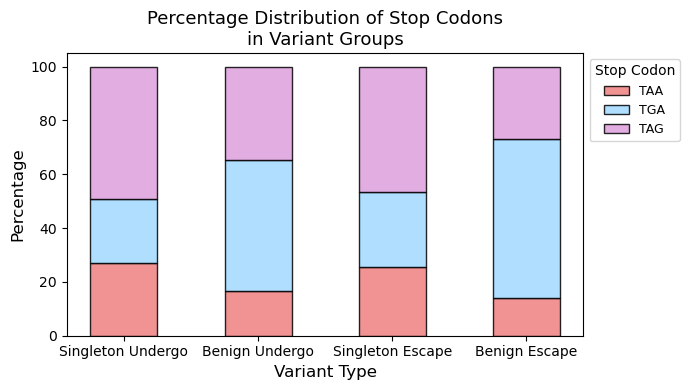

In [17]:
stop_codon_types = ['TAA', 'TGA', 'TAG']
variant_types = ['Singleton Undergo', 'Benign Undergo', 'Singleton Escape', 'Benign Escape']
x = np.arange(len(variant_types))

colors = ['#f08080', '#a1d9ff', '#dda0dd']

fig, ax = plt.subplots(figsize=(7, 4))

bottom_values = np.zeros(len(variant_types))

for stop_codon, color in zip(stop_codon_types, colors):
    values = stop_codon_df.loc[stop_codon].values
    ax.bar(x, values, width=0.5, label=stop_codon, color=color, bottom=bottom_values, edgecolor='black', alpha=0.85)
    bottom_values += values

ax.set_xticks(x)
ax.set_xticklabels(variant_types, fontsize=10)
ax.set_xlabel('Variant Type', fontsize=12)
ax.set_ylabel('Percentage', fontsize=12)
ax.set_title('Percentage Distribution of Stop Codons\nin Variant Groups', fontsize=13)

plt.legend(title='Stop Codon', fontsize=9, loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()


### 2-B. Bar plot of mutated (initial) codons in all four groups of variants

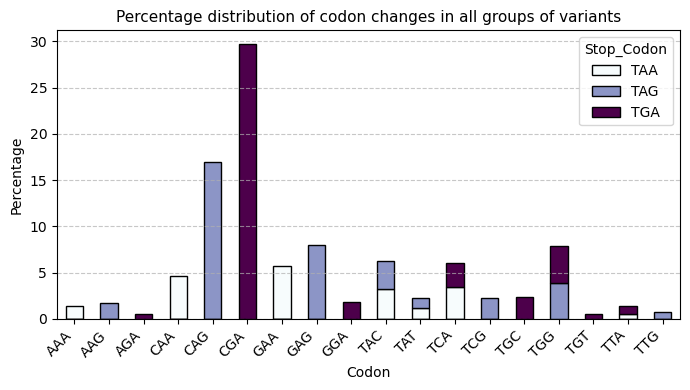

In [18]:
all_nmd['Codon_change'] = list(zip(all_nmd['Initial_Codon'], all_nmd['Stop_Codon']))  # to avoid str type
codon_change_percent = all_nmd['Codon_change'].value_counts(normalize=True) * 100

codon_change_percent_df = codon_change_percent.reset_index()
codon_change_percent_df.columns = ['Codon_change', 'Percentage']

codon_change_percent_df['Initial_Codon'] = codon_change_percent_df['Codon_change'].apply(lambda x: x[0])
codon_change_percent_df['Stop_Codon'] = codon_change_percent_df['Codon_change'].apply(lambda x: x[1])

pivot_df = codon_change_percent_df.pivot_table(values='Percentage', index='Initial_Codon', columns='Stop_Codon', fill_value=0)

fig, ax = plt.subplots(figsize=(7, 4))
pivot_df.plot(kind='bar', stacked=True, ax=ax, colormap='BuPu', edgecolor='black')

plt.title('Percentage distribution of codon changes in all groups of variants', fontsize=11)
plt.xlabel('Codon', fontsize=10)
plt.ylabel('Percentage', fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.savefig('../images/codon_change_distribution_stacked.png', dpi=300)

plt.show()

### 2-B. Bar plot of mutated (initial) codons in all four groups of variants

In [19]:
def barplot_codon_change(df_list, titles, save_path=None):
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    axes = axes.flatten()
    
    for i, df in enumerate(df_list):
        df = df.copy()
        df['Codon_change'] = list(zip(df['Initial_Codon'], df['Stop_Codon']))
        codon_change_percent = df['Codon_change'].value_counts(normalize=True) * 100
        codon_change_percent_df = codon_change_percent.reset_index()
        codon_change_percent_df.columns = ['Codon_change', 'Percentage']
        
        codon_change_percent_df['Initial_Codon'] = codon_change_percent_df['Codon_change'].apply(lambda x: x[0])
        codon_change_percent_df['Stop_Codon'] = codon_change_percent_df['Codon_change'].apply(lambda x: x[1])
        
        pivot_df = codon_change_percent_df.pivot_table(values='Percentage', index='Initial_Codon', columns='Stop_Codon', fill_value=0)
        
        pivot_df.plot(kind='bar', stacked=True, ax=axes[i], colormap='BuPu', edgecolor='black')
        
        axes[i].set_title(f"{titles[i]}", fontsize=11)
        axes[i].set_xlabel('Initial_Codon', fontsize=10)
        axes[i].set_ylabel('Percentage', fontsize=10)
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300)
    
    plt.show()

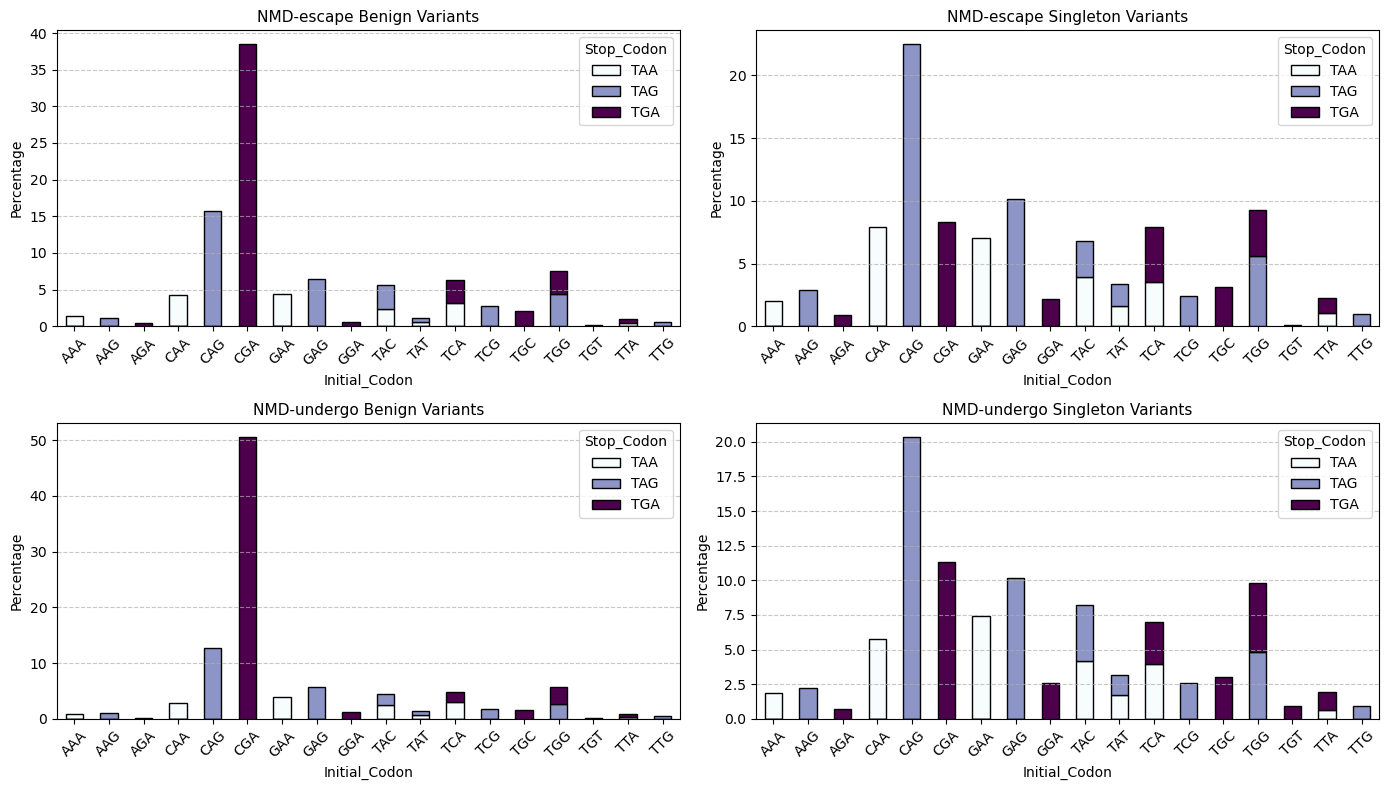

In [20]:
barplot_codon_change([ben_escape_variants, pat_escape_variants, ben_undergo_variants, pat_undergo_variants], 
                              ['NMD-escape Benign Variants', 'NMD-escape Singleton Variants', 
                               'NMD-undergo Benign Variants', 'NMD-undergo Singleton Variants'])


### 2B-i. An additional plot - transition matrix heatmap between all possible initial codons and all resulting stop codons (OX - stop codon, OY - original codon) for each of the four sets of variants

In [21]:
def heatmap_codon_change(df_list, titles, save_path=None):
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    axes = axes.flatten()
    
    for i, df in enumerate(df_list):
        df = df.copy()
        heatmap_data = df.pivot_table(index='Initial_Codon', columns='Stop_Codon', aggfunc='size', fill_value=0)
        sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='BuPu', ax=axes[i])
        
        axes[i].set_title(f"{titles[i]}", fontsize=11)
        axes[i].set_xlabel('Stop Codon', fontsize=10)
        axes[i].set_ylabel('Original Codon', fontsize=10)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300)
    
    plt.show()

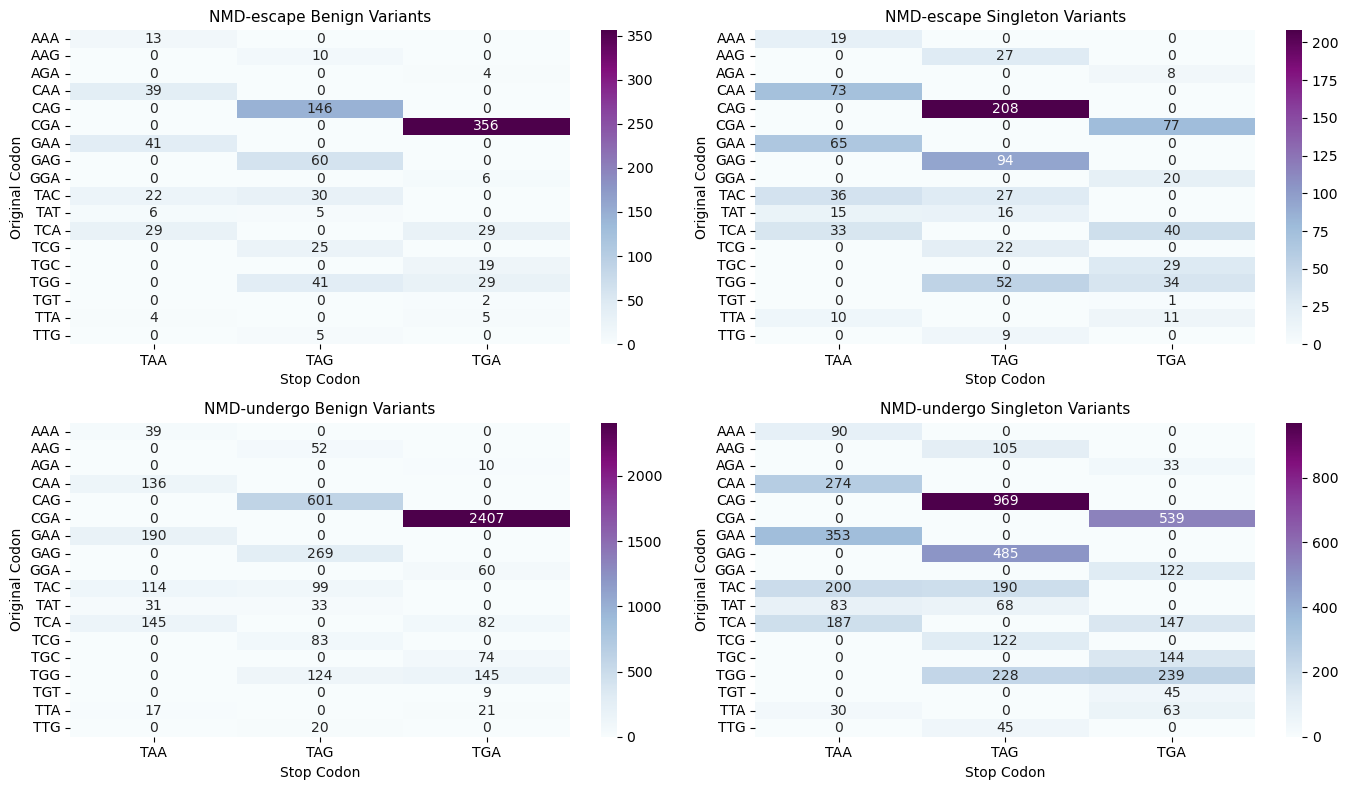

In [22]:
heatmap_codon_change([ben_escape_variants, pat_escape_variants, ben_undergo_variants, pat_undergo_variants], 
                              ['NMD-escape Benign Variants', 'NMD-escape Singleton Variants', 
                               'NMD-undergo Benign Variants', 'NMD-undergo Singleton Variants'])